In [198]:
import pandas as pd
import csv
import re
import requests
import glob
from rapidfuzz import process, fuzz
import polars as pl
import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as ctx

In [78]:
df=pd.read_csv("dpe03nouvelle_acquitaine_vf.csv" ,sep=",")

In [79]:
df.isna().sum()

numero_dpe                                0
date_etablissement_dpe                    0
methode_application_dpe                   0
etiquette_dpe                             0
etiquette_ges                             0
adresse_ban                             369
nom_commune_ban                           0
nom_rue_ban                           23926
code_postal_ban                           0
code_insee_ban                            0
code_departement_ban                      0
code_region_ban                           0
coordonnee_cartographique_x_ban           0
coordonnee_cartographique_y_ban           0
score_ban                                 0
adresse_complete_brut                     2
type_batiment                             0
surface_habitable_logement            11988
annee_construction                   255745
nombre_niveau_logement                12864
hauteur_sous_plafond                      0
zone_climatique                        2499
emission_ges_chauffage          

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564747 entries, 0 to 564746
Data columns (total 42 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   numero_dpe                         564747 non-null  object 
 1   date_etablissement_dpe             564747 non-null  object 
 2   methode_application_dpe            564747 non-null  object 
 3   etiquette_dpe                      564747 non-null  object 
 4   etiquette_ges                      564747 non-null  object 
 5   adresse_ban                        564378 non-null  object 
 6   nom_commune_ban                    564747 non-null  object 
 7   nom_rue_ban                        540821 non-null  object 
 8   code_postal_ban                    564747 non-null  int64  
 9   code_insee_ban                     564747 non-null  int64  
 10  code_departement_ban               564747 non-null  int64  
 11  code_region_ban                    5647

In [81]:
df.head()

,numero_dpe,date_etablissement_dpe,methode_application_dpe,etiquette_dpe,etiquette_ges,adresse_ban,nom_commune_ban,nom_rue_ban,code_postal_ban,code_insee_ban,...,conso_ecs_ef,conso_chauffage_ef,conso_ecs_ep,conso_chauffage_ep,adresse_brut,nom_commune_brut,code_postal_brut,type_installation_chauffage,type_installation_ecs,date_fin_validite_dpe
0,2633E0007887V,2026-01-05,dpe maison individuelle,C,A,Fleur 33490 Saint-Maixant,Saint-Maixant,Fleur,33490,33438,...,2056.2,4303.3,3906.7,8176.2,9 Quartier Fleur,ST MAIXANT,33490,NaN,NaN,2036-01-04
1,2647E0006686E,2026-01-04,dpe maison individuelle,B,A,3 Rue des Cosmonautes 47300 Pujols,Pujols,Rue des Cosmonautes,47300,47215,...,315.2,4952.4,598.9,9409.5,3 Rue des Cosmonautes,"Pujols, France",47300,NaN,NaN,2036-01-03
2,2633E0027829V,2026-01-06,dpe appartement individuel,C,B,51 Cours Victor Hugo 33000 Bordeaux,Bordeaux,Cours Victor Hugo,33000,33063,...,1805.1,3776.2,3429.7,7174.8,51 Cours Victor Hugo,"Bordeaux, France",33000,individuel,individuel,2036-01-05
3,2133E0823275S,2021-12-01,dpe maison individuelle,F,F,111 Rue Lamartine 33400 Talence,Talence,Rue Lamartine,33400,33522,...,2628.7,31948.7,2628.7,31948.7,111 RUE LAMARTINE,TALENCE,33400,NaN,NaN,2031-11-30
4,2679E0051495V,2026-01-08,dpe maison individuelle,C,B,29 Rue de l’Abbaye 79160 Villiers-en-Plaine,Villiers-en-Plaine,Rue de l’Abbaye,79160,79351,...,2732.5,16306.5,5191.7,24671.2,29 Rue de l'Abbaye,VILLIERS-EN-PLAINE,79160,NaN,NaN,2036-01-07


Compte tenu du nombre important des variables, nous allons en choisir que les éssentielles.

In [82]:
df['conso_5_usages_ef']=df["conso_5 usages_ef"].rename("conso_5_usages_ef")
cols = [
    'date_etablissement_dpe', 'etiquette_dpe', 'etiquette_ges',
    'adresse_ban', 'coordonnee_cartographique_x_ban', 'coordonnee_cartographique_y_ban',
    'code_postal_ban', 'code_departement_ban', 'nom_commune_ban','code_insee_ban',
    'type_batiment', 'surface_habitable_logement', 'annee_construction',
    'conso_5_usages_ef', 'type_energie_principale_chauffage'
]
df = df[cols]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564747 entries, 0 to 564746
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   date_etablissement_dpe             564747 non-null  object 
 1   etiquette_dpe                      564747 non-null  object 
 2   etiquette_ges                      564747 non-null  object 
 3   adresse_ban                        564378 non-null  object 
 4   coordonnee_cartographique_x_ban    564747 non-null  float64
 5   coordonnee_cartographique_y_ban    564747 non-null  float64
 6   code_postal_ban                    564747 non-null  int64  
 7   code_departement_ban               564747 non-null  int64  
 8   nom_commune_ban                    564747 non-null  object 
 9   code_insee_ban                     564747 non-null  int64  
 10  type_batiment                      564747 non-null  object 
 11  surface_habitable_logement         5527

## Netoyage des données

### Conversion des types des variables

Les Dates

In [83]:
df['date_etablissement_dpe'] = pd.to_datetime(df['date_etablissement_dpe'], errors='coerce')
df['date_etablissement_dpe'].min()

Timestamp('2021-07-01 00:00:00')

les Variables numériques

In [84]:
num_cols = [
    'surface_habitable_logement',
    'annee_construction',
    'conso_5_usages_ef',
    'coordonnee_cartographique_x_ban',
    'coordonnee_cartographique_y_ban'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Les codes

In [85]:
df['code_postal_ban'] = df['code_postal_ban'].astype(str)
df['code_departement_ban'] = df['code_departement_ban'].astype(str)

Nettoyage des étiquettes énergétiques
Les classes DPE doivent être A → G.

In [86]:
classes_valides = list("ABCDEFG")

df = df[df['etiquette_dpe'].isin(classes_valides)]
df = df[df['etiquette_ges'].isin(classes_valides)]

Encodage des étiquettes DPE

In [87]:
dpe_map = {
    'A':7,
    'B':6,
    'C':5,
    'D':4,
    'E':3,
    'F':2,
    'G':1
}

df['score_dpe'] = df['etiquette_dpe'].map(dpe_map)

### Les valeurs abérantes

#### Consommation et Surface habitable

<Axes: xlabel='surface_habitable_logement', ylabel='conso_5_usages_ef'>

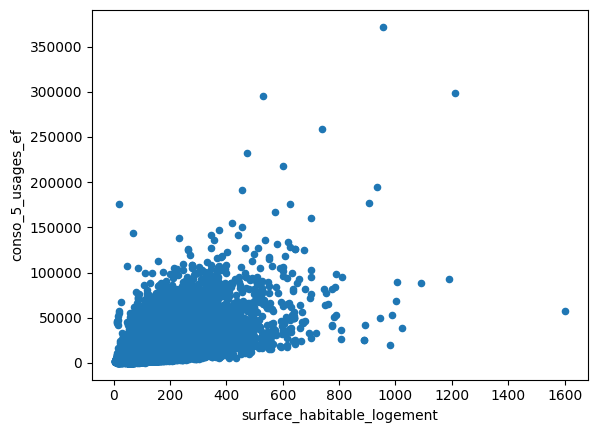

In [88]:
df.plot.scatter(x='surface_habitable_logement', y='conso_5_usages_ef')

Nous observons une correlation positive entre la consommation et la surface habitale ce qui est logique.
Nous pouvons également remarquer quelque outliers sur les deux axes.

Surface habitable
On supprime les surfaces absurdes.

In [89]:
df=df[(df["surface_habitable_logement"] > 5)]

consommation énergetique

In [90]:
df = df[(df['conso_5_usages_ef'] > 0)]

Nous allons maintenant créer une variable qui mesure la consommation par m² et ensuite nous filtrerons pour avoir limité les erreurs de saisies.
Cela pour cadrer un la surface habitable ainsi que la consommation dans un intervalle raisonnable

In [91]:
df["conso_m2"] = df["conso_5_usages_ef"] / df["surface_habitable_logement"]

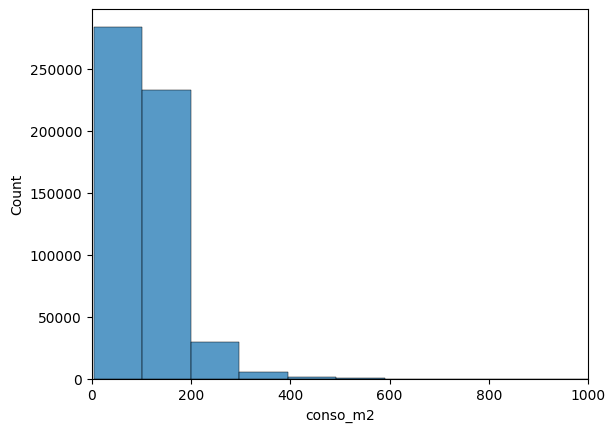

In [92]:
sns.histplot(df["conso_m2"], bins=100)
plt.xlim(0,1000)
plt.show()

In [93]:
df=df[(df["conso_m2"] >20)& (df["conso_m2"] < 600)]

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550828 entries, 0 to 564746
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date_etablissement_dpe             550828 non-null  datetime64[ns]
 1   etiquette_dpe                      550828 non-null  object        
 2   etiquette_ges                      550828 non-null  object        
 3   adresse_ban                        550460 non-null  object        
 4   coordonnee_cartographique_x_ban    550828 non-null  float64       
 5   coordonnee_cartographique_y_ban    550828 non-null  float64       
 6   code_postal_ban                    550828 non-null  object        
 7   code_departement_ban               550828 non-null  object        
 8   nom_commune_ban                    550828 non-null  object        
 9   code_insee_ban                     550828 non-null  int64         
 10  type_batiment            

### Gestion des valeurs manquantes

Nous avons déjà supprimer pas mal de valeurs manquantes avec les filtrages sur nos variables indispensables. Nous allons maintenant imputer ou supprimer les restantes

In [95]:
df.isna().sum()

date_etablissement_dpe                    0
etiquette_dpe                             0
etiquette_ges                             0
adresse_ban                             368
coordonnee_cartographique_x_ban           0
coordonnee_cartographique_y_ban           0
code_postal_ban                           0
code_departement_ban                      0
nom_commune_ban                           0
code_insee_ban                            0
type_batiment                             0
surface_habitable_logement                0
annee_construction                   248440
conso_5_usages_ef                         0
type_energie_principale_chauffage         0
score_dpe                                 0
conso_m2                                  0
dtype: int64

Vu le nombre de valeurs manquantes importantes sur la variable année de contruction, nous les imputer plutôt que de les supprimer.

In [96]:
def periode_construction(x):
    if pd.isna(x):
        return "Inconnue"
    elif x < 1948:
        return "Avant 1948"
    elif x < 1975:
        return "1948-1974"
    elif x < 1990:
        return "1975-1989"
    elif x < 2005:
        return "1990-2004"
    else:
        return "Après 2005"

df["periode_construction"] = df["annee_construction"].apply(periode_construction)
df = df.drop(columns=["annee_construction"])

In [97]:
df["periode_construction"].value_counts()

periode_construction
Inconnue      248440
Après 2005     76364
Avant 1948     73070
1975-1989      53708
1948-1974      51316
1990-2004      47930
Name: count, dtype: int64

In [98]:
df=df.dropna(subset=["adresse_ban"])
df.isna().sum()

date_etablissement_dpe               0
etiquette_dpe                        0
etiquette_ges                        0
adresse_ban                          0
coordonnee_cartographique_x_ban      0
coordonnee_cartographique_y_ban      0
code_postal_ban                      0
code_departement_ban                 0
nom_commune_ban                      0
code_insee_ban                       0
type_batiment                        0
surface_habitable_logement           0
conso_5_usages_ef                    0
type_energie_principale_chauffage    0
score_dpe                            0
conso_m2                             0
periode_construction                 0
dtype: int64

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550460 entries, 0 to 564746
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date_etablissement_dpe             550460 non-null  datetime64[ns]
 1   etiquette_dpe                      550460 non-null  object        
 2   etiquette_ges                      550460 non-null  object        
 3   adresse_ban                        550460 non-null  object        
 4   coordonnee_cartographique_x_ban    550460 non-null  float64       
 5   coordonnee_cartographique_y_ban    550460 non-null  float64       
 6   code_postal_ban                    550460 non-null  object        
 7   code_departement_ban               550460 non-null  object        
 8   nom_commune_ban                    550460 non-null  object        
 9   code_insee_ban                     550460 non-null  int64         
 10  type_batiment            

### Les doublons

In [100]:
df.duplicated().sum()


np.int64(20412)

Nous avons plus de 20000 doublons, nous allons les supprimer 

In [101]:
df = df.drop_duplicates()

### Vérification finale

In [102]:
print(df.info())
print(df.describe())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 530048 entries, 0 to 564746
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date_etablissement_dpe             530048 non-null  datetime64[ns]
 1   etiquette_dpe                      530048 non-null  object        
 2   etiquette_ges                      530048 non-null  object        
 3   adresse_ban                        530048 non-null  object        
 4   coordonnee_cartographique_x_ban    530048 non-null  float64       
 5   coordonnee_cartographique_y_ban    530048 non-null  float64       
 6   code_postal_ban                    530048 non-null  object        
 7   code_departement_ban               530048 non-null  object        
 8   nom_commune_ban                    530048 non-null  object        
 9   code_insee_ban                     530048 non-null  int64         
 10  type_batiment            

### Dataset final

In [121]:
df_clean = df.copy()

## CONSOMMATION ENEDIS

In [148]:
consommation=pd.read_csv("consommation-annuelle-residentielle-par-adresse (1).csv" ,sep=";")
df_consommation = consommation[consommation['Code Région'].astype(str).str.startswith("75")]
df_consommation=df_consommation[consommation["Année"]>2020] 

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2847080377.py:1: DtypeWarning: Columns (1,15) have mixed types. Specify dtype option on import or set low_memory=False.
  consommation=pd.read_csv("consommation-annuelle-residentielle-par-adresse (1).csv" ,sep=";")
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2847080377.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_consommation=df_consommation[consommation["Année"]>2020]


Nous filtrons Année sur 2020 comme demander dans les consignes (puisqu'on travaille sur les données de DPE disponible qu'à partir de juillet 2021)

In [149]:
df_consommation.head()

,Année,Code IRIS,Nom IRIS,Numéro de voie,Indice de répétition,Type de voie,Libellé de voie,Code Commune,Nom Commune,Segment de client,Nombre de logements,Consommation annuelle totale de l'adresse (MWh),Consommation annuelle moyenne par logement de l'adresse (MWh),Consommation annuelle moyenne de la commune (MWh),Adresse,Code EPCI,Code Département,Code Région,Tri des adresses
142033,2021,470010111,Montanou,5.0,NaN,RUE,BLAISE DE MONLUC,47001,Agen,RESIDENTIEL,56,83.869,1.498,3.198,5 RUE BLAISE DE MONLUC,200096956.0,47.0,75.0,1058
142034,2021,470010101,Centre Urbain 1,117.0,NaN,BOULEVARD,CARNOT,47001,Agen,RESIDENTIEL,27,31.891,1.181,3.198,117 BOULEVARD CARNOT,200096956.0,47.0,75.0,1065
142035,2021,470010107,Ouest Urbain,69.0,NaN,BOULEVARD,DE LA LIBERTE,47001,Agen,RESIDENTIEL,19,78.599,4.137,3.198,69 BOULEVARD DE LA LIBERTE,200096956.0,47.0,75.0,1086
142036,2021,470010112,Nord-Est Urbain,62.0,NaN,RUE,DE LA PRUNE,47001,Agen,RESIDENTIEL,10,31.502,3.150,3.198,62 RUE DE LA PRUNE,200096956.0,47.0,75.0,1089
142037,2021,470010108,Nord Urbain 1,9.0,NaN,RUE,DE LA REINE,47001,Agen,RESIDENTIEL,16,25.604,1.600,3.198,9 RUE DE LA REINE,200096956.0,47.0,75.0,1090


### Selection des variables utiles

In [150]:
cols_enedis = [
    "Code Commune",
    "Nom Commune",
    "Adresse",
    "Année",
    "Segment de client",
    "Consommation annuelle totale de l'adresse (MWh)",
    "Consommation annuelle moyenne par logement de l'adresse (MWh)",
    'Consommation annuelle moyenne de la commune (MWh)',
    "Nombre de logements"
]

df_consommation = df_consommation[cols_enedis]

In [151]:
df_consommation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84948 entries, 142033 to 2820482
Data columns (total 9 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Code Commune                                                   84948 non-null  int64  
 1   Nom Commune                                                    84948 non-null  object 
 2   Adresse                                                        84948 non-null  object 
 3   Année                                                          84948 non-null  int64  
 4   Segment de client                                              84948 non-null  object 
 5   Consommation annuelle totale de l'adresse (MWh)                84948 non-null  float64
 6   Consommation annuelle moyenne par logement de l'adresse (MWh)  84948 non-null  float64
 7   Consommation annuelle moyenne de la commune (MWh)        

In [152]:
df_consommation.isna().sum()

Code Commune                                                     0
Nom Commune                                                      0
Adresse                                                          0
Année                                                            0
Segment de client                                                0
Consommation annuelle totale de l'adresse (MWh)                  0
Consommation annuelle moyenne par logement de l'adresse (MWh)    0
Consommation annuelle moyenne de la commune (MWh)                0
Nombre de logements                                              0
dtype: int64

In [153]:
df_consommation.duplicated().sum()

np.int64(0)

A priori pas de doublons, ni de valeurs manquantes.

Nettoyage des types

In [154]:
df_consommation["Année"] = pd.to_numeric(df_consommation["Année"], errors="coerce")

df_consommation["Consommation annuelle moyenne par logement de l'adresse (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle moyenne par logement de l'adresse (MWh)"], errors="coerce"
)

df_consommation["Consommation annuelle totale de l'adresse (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle totale de l'adresse (MWh)"], errors="coerce"
)


df_consommation["Consommation annuelle moyenne de la commune (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle moyenne de la commune (MWh)"], errors="coerce"
)


df_consommation["Nombre de logements"] = pd.to_numeric(df_consommation["Nombre de logements"], errors="coerce")

df_consommation["Code Commune"] = df_consommation["Code Commune"].astype(str)


#### Standardiser les noms de communes

In [155]:
df_consommation["Nom Commune"] = (
    df_consommation["Nom Commune"]
    .str.upper()
    .str.strip()
)

### Vérification finale

In [156]:
print(df_consommation.info())
print(df_consommation.describe())
print(df_consommation.isna().sum())
print(df_consommation.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 84948 entries, 142033 to 2820482
Data columns (total 9 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Code Commune                                                   84948 non-null  object 
 1   Nom Commune                                                    84948 non-null  object 
 2   Adresse                                                        84948 non-null  object 
 3   Année                                                          84948 non-null  int64  
 4   Segment de client                                              84948 non-null  object 
 5   Consommation annuelle totale de l'adresse (MWh)                84948 non-null  float64
 6   Consommation annuelle moyenne par logement de l'adresse (MWh)  84948 non-null  float64
 7   Consommation annuelle moyenne de la commune (MWh)        

## Préparation de la jointure des deux tables ( Données DPE et Données consommation Enedis)

In [157]:
df_clean["adresse_ban"]=df_clean["adresse_ban"].str.replace(r'\d{5}.*$', '', regex=True)     # Supprime Code Postal + Ville



df_clean["Adresse_complete"]=df_clean["adresse_ban"].fillna("").astype(str).str.strip() + " " + df_clean["code_insee_ban"].fillna("").astype(str) + " " + df_clean["nom_commune_ban"].fillna("").astype(str)
df_clean["Adresse_complete"]= df_clean["Adresse_complete"].str.upper()


df_consommation["Adresse_complete"]=df_consommation["Adresse"].fillna("").astype(str).str.strip() + " " + df_consommation["Code Commune"].fillna("").astype(str) + " " + df_consommation["Nom Commune"].fillna("").astype(str)
df_consommation["Adresse_complete"]= df_consommation["Adresse_complete"].str.upper()

In [158]:
Dpe_enedis=pd.merge(df_clean, df_consommation, on="Adresse_complete", how="inner")
Dpe_enedis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206836 entries, 0 to 206835
Data columns (total 27 columns):
 #   Column                                                         Non-Null Count   Dtype         
---  ------                                                         --------------   -----         
 0   date_etablissement_dpe                                         206836 non-null  datetime64[ns]
 1   etiquette_dpe                                                  206836 non-null  object        
 2   etiquette_ges                                                  206836 non-null  object        
 3   adresse_ban                                                    206836 non-null  object        
 4   coordonnee_cartographique_x_ban                                206836 non-null  float64       
 5   coordonnee_cartographique_y_ban                                206836 non-null  float64       
 6   code_postal_ban                                                206836 non-null  obje

In [159]:
print(Dpe_enedis.isna().sum())
print(Dpe_enedis.duplicated().sum())

date_etablissement_dpe                                           0
etiquette_dpe                                                    0
etiquette_ges                                                    0
adresse_ban                                                      0
coordonnee_cartographique_x_ban                                  0
coordonnee_cartographique_y_ban                                  0
code_postal_ban                                                  0
code_departement_ban                                             0
nom_commune_ban                                                  0
code_insee_ban                                                   0
type_batiment                                                    0
surface_habitable_logement                                       0
conso_5_usages_ef                                                0
type_energie_principale_chauffage                                0
score_dpe                                                     

In [160]:
Dpe_enedis.to_csv("dpe03nouvelle_acquitaine_enedis.csv", index=False)

In [161]:
Dpe_enedis.head()

,date_etablissement_dpe,etiquette_dpe,etiquette_ges,adresse_ban,coordonnee_cartographique_x_ban,coordonnee_cartographique_y_ban,code_postal_ban,code_departement_ban,nom_commune_ban,code_insee_ban,...,Adresse_complete,Code Commune,Nom Commune,Adresse,Année,Segment de client,Consommation annuelle totale de l'adresse (MWh),Consommation annuelle moyenne par logement de l'adresse (MWh),Consommation annuelle moyenne de la commune (MWh),Nombre de logements
0,2022-06-13,F,D,11 Rue des Acacias,521460.47,6457513.30,24000,24,Périgueux,24322,...,11 RUE DES ACACIAS 24322 PÉRIGUEUX,24322,PÉRIGUEUX,11 RUE DES ACACIAS,2021,RESIDENTIEL,207.236,3.910,3.122,53
1,2022-06-13,F,D,11 Rue des Acacias,521460.47,6457513.30,24000,24,Périgueux,24322,...,11 RUE DES ACACIAS 24322 PÉRIGUEUX,24322,PÉRIGUEUX,11 RUE DES ACACIAS,2023,RESIDENTIEL,168.370,3.238,2.800,52
2,2022-06-13,F,D,11 Rue des Acacias,521460.47,6457513.30,24000,24,Périgueux,24322,...,11 RUE DES ACACIAS 24322 PÉRIGUEUX,24322,PÉRIGUEUX,11 RUE DES ACACIAS,2024,RESIDENTIEL,160.253,3.082,2.793,52
3,2022-06-13,F,D,11 Rue des Acacias,521460.47,6457513.30,24000,24,Périgueux,24322,...,11 RUE DES ACACIAS 24322 PÉRIGUEUX,24322,PÉRIGUEUX,11 RUE DES ACACIAS,2022,RESIDENTIEL,168.302,3.237,2.907,52
4,2026-01-05,D,B,104 Rue du Faubourg Saint Cyprien,496498.37,6611231.36,86000,86,Poitiers,86194,...,104 RUE DU FAUBOURG SAINT CYPRIEN 86194 POITIERS,86194,POITIERS,104 RUE DU FAUBOURG SAINT CYPRIEN,2023,RESIDENTIEL,71.842,1.996,2.828,36



# Réponses aux problématiques

In [162]:
df_final = Dpe_enedis.copy()

## Vérifier la distribution des classes DPE

In [163]:
A=df_final['etiquette_dpe'].value_counts().sort_index()
percentages = (A / A.sum()) * 100
for label, percentage in percentages.items():
    print(f"{label}: {percentage:.2f}%")

A: 0.69%
B: 5.45%
C: 57.79%
D: 26.53%
E: 7.14%
F: 1.62%
G: 0.77%


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\937141456.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


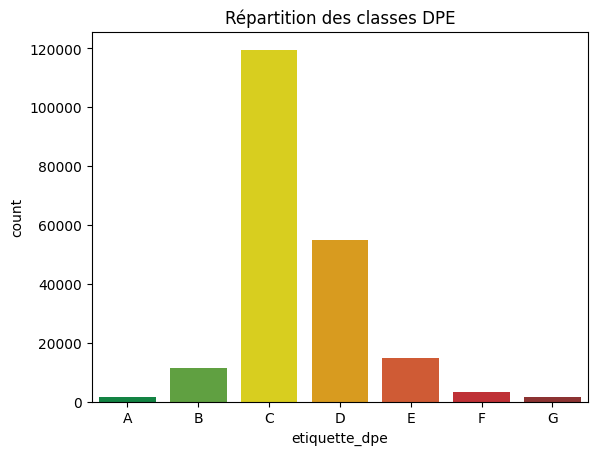

In [164]:
couleurs_dpe = {
    "A": "#009640",
    "B": "#5AB031",
    "C": "#F7EA00",
    "D": "#F7A600",
    "E": "#E94E1B",
    "F": "#D71920",
    "G": "#9B2423"
}

ordre = list("ABCDEFG")

sns.countplot(
    data=df_final,
    x="etiquette_dpe",
    order=ordre,
    palette=[couleurs_dpe[c] for c in ordre]
)

plt.title("Répartition des classes DPE")
plt.show()


La répartition des classes DPE met en évidence un parc immobilier globalement situé dans la moyenne nationale, avec une forte concentration de logements classés C et D, qui constituent le cœur du graphique. Ces deux catégories traduisent des bâtiments offrant une performance énergétique correcte mais perfectible, souvent associés à des constructions d’après‑guerre ou à des logements ayant bénéficié de rénovations partielles. Les classes E, F et G, bien que présentes, restent moins représentées : elles correspondent aux logements les plus énergivores, généralement anciens et peu isolés, mais leur proportion limitée indique que les “passoires thermiques” ne dominent pas l’échantillon. À l’inverse, les classes A et B apparaissent très marginales, ce qui est cohérent avec un territoire où les bâtiments récents ou très performants restent minoritaires. Dans l’ensemble, cette distribution suggère un parc immobilier plutôt ancien, hétérogène, mais sans concentration excessive de logements très dégradés sur le plan énergétique.

## Consommation estimée par classe DPE

In [165]:
conso_dpe = df_final.groupby("etiquette_dpe")["conso_5_usages_ef"].mean()
print(conso_dpe)

etiquette_dpe
A    1935.544140
B    3220.358870
C    3843.721196
D    5057.450369
E    6538.976727
F    8265.281574
G    9477.492317
Name: conso_5_usages_ef, dtype: float64


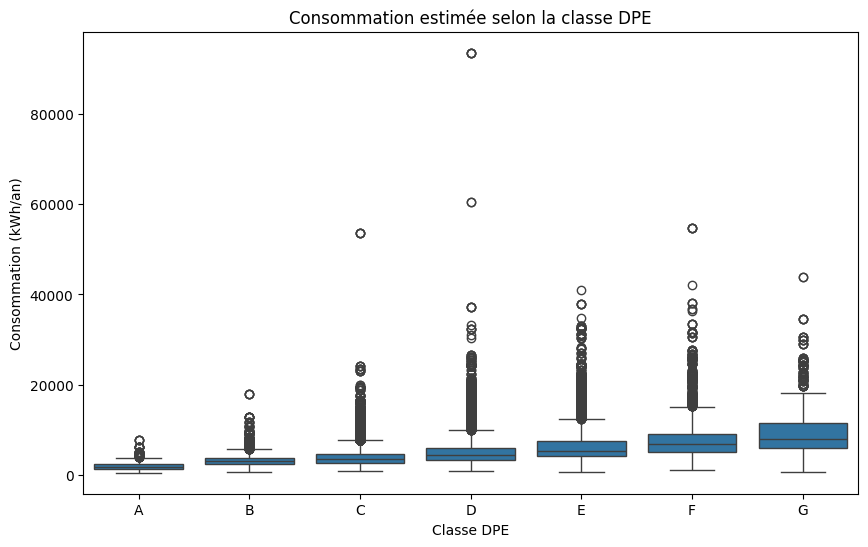

In [166]:
plt.figure(figsize=(10,6))

# Création du boxplot
ax = sns.boxplot(
    data=df_final,
    x="etiquette_dpe",
    y="conso_5_usages_ef",
    order=ordre
)

# Application des couleurs officielles
for patch, classe in zip(ax.artists, ordre):
    patch.set_facecolor(couleurs_dpe[classe])

plt.title("Consommation estimée selon la classe DPE")
plt.xlabel("Classe DPE")
plt.ylabel("Consommation (kWh/an)")
plt.show()


Avec La représentation en boxplots de la consommation énergétique selon les classes DPE  nous remarquons une progression nette et cohérente entre les catégories. Les classes les mieux notées, comme A, B et C, présentent des niveaux de consommation nettement plus faibles et des distributions resserrées, traduisant des logements performants et relativement homogènes. À partir de la classe D, la dispersion augmente, signe d’une plus grande hétérogénéité des bâtiments et de leurs niveaux d’isolation. Les classes E, F et surtout G affichent des consommations médianes nettement plus élevées, accompagnées de nombreux points atypiques, ce qui reflète la présence de logements très énergivores, souvent anciens ou mal rénovés. L’ensemble confirme la logique du DPE : plus la classe est dégradée, plus la consommation estimée augmente, tant en valeur centrale qu’en variabilité.

## Comparaison  consommation dpe et consommation réelle

In [167]:
df_final["Consommation annuelle totale de l'adresse (kWh)"]=df_final["Consommation annuelle totale de l'adresse (MWh)"]*1000
df_final["Consommation annuelle moyenne par logement de l'adresse (kWh)"]=df_final["Consommation annuelle moyenne par logement de l'adresse (MWh)"]*1000

In [168]:
df_final.groupby("etiquette_dpe")[
    ["conso_5_usages_ef", "Consommation annuelle moyenne par logement de l'adresse (kWh)"]
].mean()

,conso_5_usages_ef,Consommation annuelle moyenne par logement de l'adresse (kWh)
etiquette_dpe,,
A,1935.544140,2611.315789
B,3220.358870,3495.517865
C,3843.721196,3441.790503
D,5057.450369,3121.809253
E,6538.976727,2759.490830
F,8265.281574,2675.456172
G,9477.492317,2621.288413


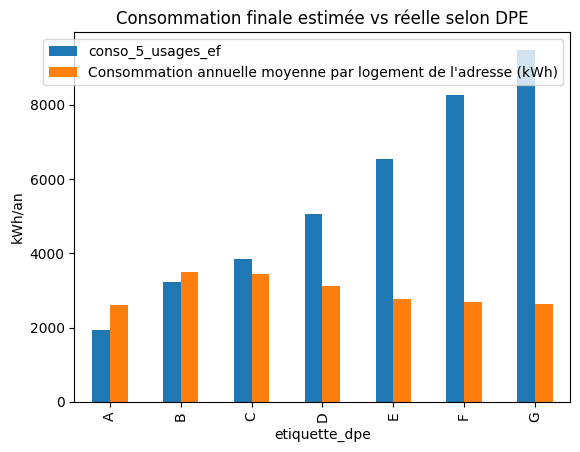

In [169]:
df_plot = df_final.groupby("etiquette_dpe")[
    ["conso_5_usages_ef", "Consommation annuelle moyenne par logement de l'adresse (kWh)"]
].mean().reset_index()

df_plot.plot(x="etiquette_dpe", kind="bar")
plt.title("Consommation finale estimée vs réelle selon DPE")
plt.ylabel("kWh/an")
plt.show()

La comparaison entre la consommation finale estimée par le DPE et la consommation réelle mesurée par Enedis met en évidence une cohérence globale dans la hiérarchie énergétique des logements : les classes les mieux notées (A, B, C) présentent des niveaux de consommation plus faibles, tandis que les classes dégradées (E, F, G) affichent des valeurs nettement plus élevées. Toutefois, on observe systématiquement que les consommations réelles sont inférieures aux consommations estimées par le modèle réglementaire du DPE. Cet écart s’explique par le caractère conventionnel du DPE, qui repose sur des hypothèses standardisées d’occupation et de chauffage, alors que les ménages adaptent leurs usages, notamment dans les logements énergivores où le chauffage est souvent réduit pour limiter les coûts. L’écart entre estimation et réalité devient particulièrement marqué dans les classes F et G, ce qui traduit à la fois la forte déperdition thermique de ces logements et les stratégies de restriction adoptées par leurs occupants. Au final, le graphique confirme que le DPE classe correctement les logements en termes de performance énergétique, tout en surestimant la consommation réelle, surtout dans les passoires thermiques.

### Variabilité des consommations
On regarde l’écart.

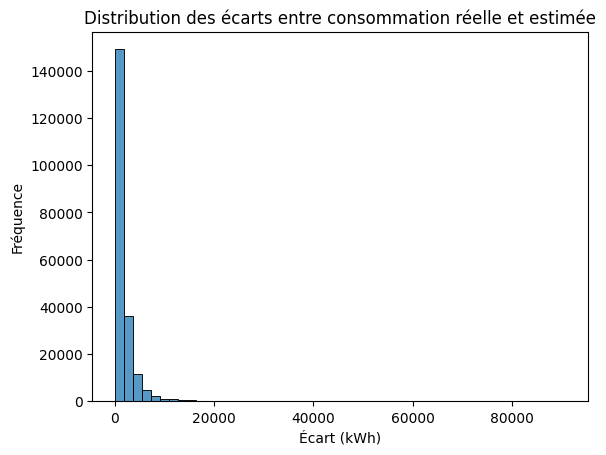

In [175]:
df_final["ecart_conso"] = abs(
    df_final["Consommation annuelle moyenne par logement de l'adresse (kWh)"] -
    df_final["conso_5_usages_ef"]
)
sns.histplot(df_final["ecart_conso"], bins=50)
plt.title("Distribution des écarts entre consommation réelle et estimée")
plt.xlabel("Écart (kWh)")
plt.ylabel("Fréquence")
plt.show()

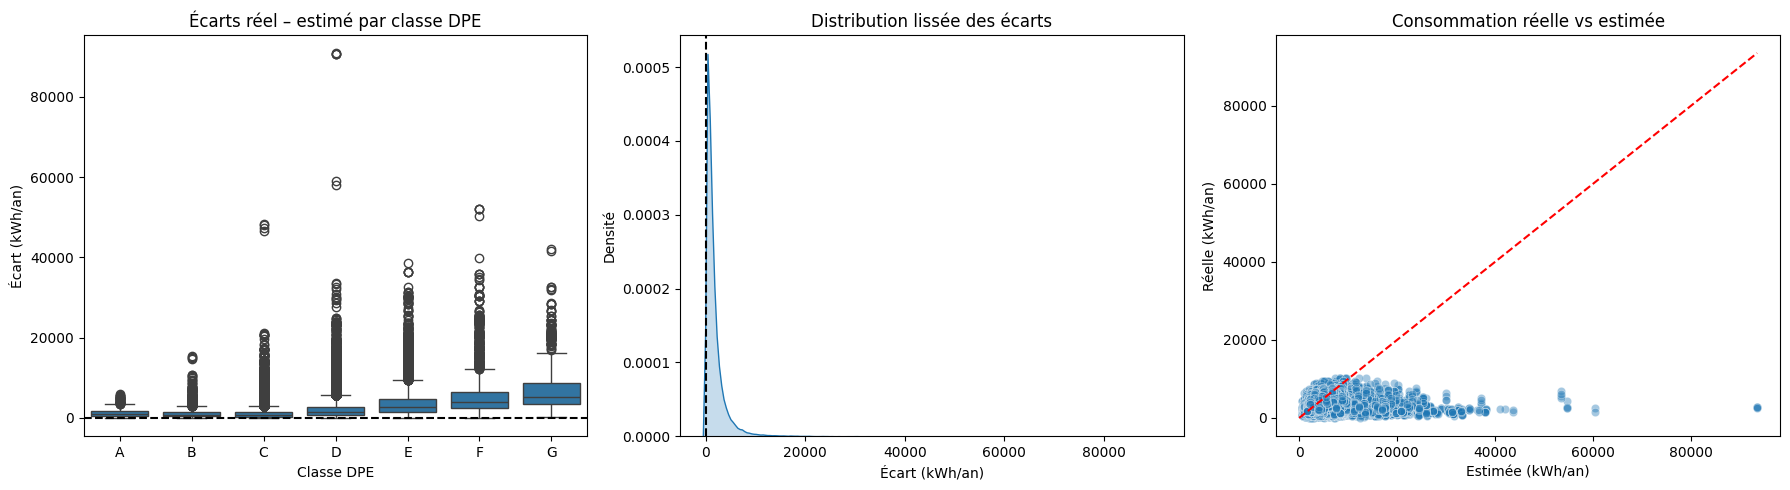

In [ ]:
plt.figure(figsize=(18,5))


plt.subplot(1, 3, 1)
sns.boxplot(
    data=df_final,
    x="etiquette_dpe",
    y="ecart",
    order=list("ABCDEFG")
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Écarts réel – estimé par classe DPE")
plt.xlabel("Classe DPE")
plt.ylabel("Écart (kWh/an)")


plt.subplot(1, 3, 2)
sns.kdeplot(df_final["ecart"], fill=True)
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribution lissée des écarts")
plt.xlabel("Écart (kWh/an)")
plt.ylabel("Densité")


plt.subplot(1, 3, 3)
sns.scatterplot(
    x=df_final["conso_5_usages_ef"],
    y=df_final["Consommation annuelle moyenne par logement de l'adresse (kWh)"],
    alpha=0.4
)
max_val = max(
    df_final["conso_5_usages_ef"].max(),
    df_final["Consommation annuelle moyenne par logement de l'adresse (kWh)"].max()
)
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--")
plt.title("Consommation réelle vs estimée")
plt.xlabel("Estimée (kWh/an)")
plt.ylabel("Réelle (kWh/an)")

plt.tight_layout()
plt.show()


L’analyse conjointe des trois graphiques nous fait remarquer la variabilité entre la consommation réelle mesurée par Enedis et la consommation finale estimée par le DPE. Le boxplot des écarts par classe DPE montre que, pour toutes les classes, les valeurs réelles s’écartent sensiblement des valeurs théoriques, avec une dispersion particulièrement marquée dans les classes énergivores (E, F, G). Cette dispersion traduit directement l’influence des comportements individuels : température de chauffage, durée d’utilisation, pièces non chauffées, sobriété volontaire ou contraintes économiques. La courbe de densité confirme cette observation en révélant une distribution fortement asymétrique, centrée sur des écarts négatifs, ce qui indique que la majorité des ménages consomment moins que ce que le modèle réglementaire prévoit. Enfin, le nuage de points réel vs estimé montre une dispersion verticale importante autour de la diagonale théorique, signe que deux logements identiques sur le plan technique peuvent présenter des consommations très différentes selon les usages. L’ensemble de ces résultats démontre que la variabilité comportementale constitue un facteur majeur d’écart entre consommation théorique et consommation observée, et qu’elle augmente nettement dans les logements les moins performants.

### Gain potentiel d'une rénovation

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2718187976.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_dpe.index, y=gain_dpe.values, palette="viridis")
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2718187976.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_diff.index, y=gain_diff.values, palette="magma")


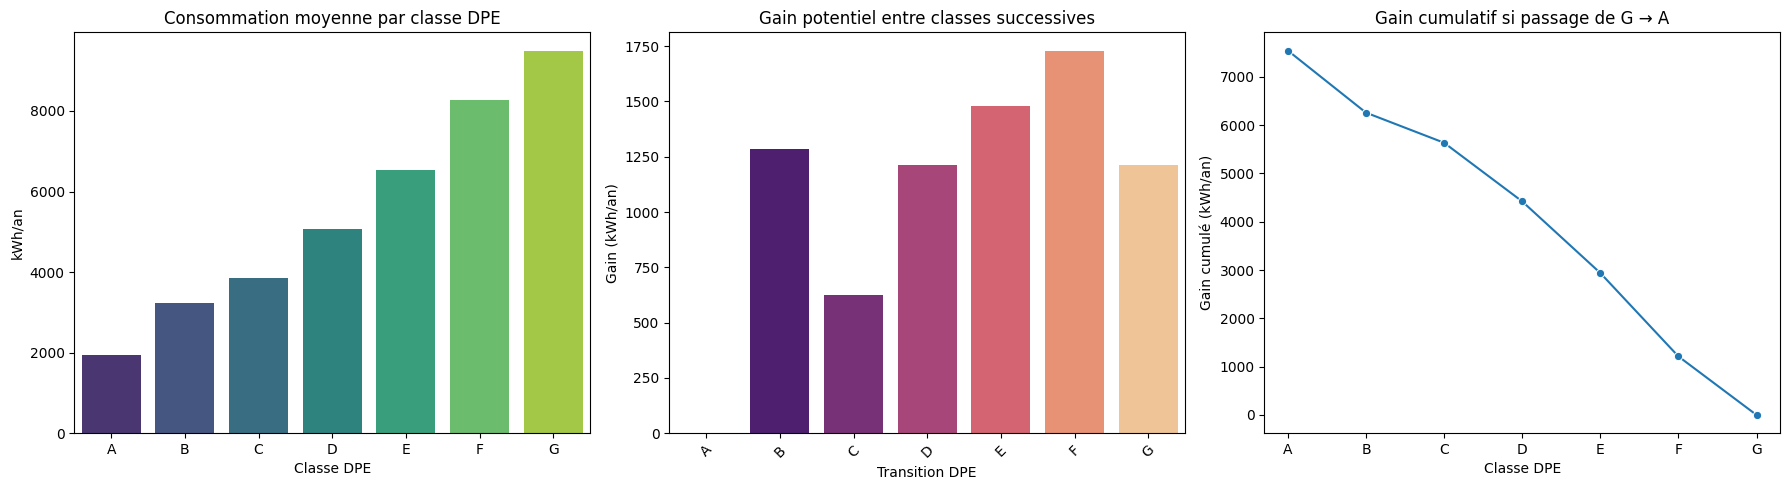

In [ ]:

# Moyenne des consommations par classe
gain_dpe = df_final.groupby("etiquette_dpe")["conso_5_usages_ef"].mean()
gain_dpe = gain_dpe.reindex(list("ABCDEFG"))

# Calcul des gains entre classes successives
gain_diff = gain_dpe.diff().abs()

plt.figure(figsize=(18,5))


plt.subplot(1, 3, 1)
sns.barplot(x=gain_dpe.index, y=gain_dpe.values, palette="viridis")
plt.title("Consommation moyenne par classe DPE")
plt.ylabel("kWh/an")
plt.xlabel("Classe DPE")


plt.subplot(1, 3, 2)
sns.barplot(x=gain_diff.index, y=gain_diff.values, palette="magma")
plt.title("Gain potentiel entre classes successives")
plt.ylabel("Gain (kWh/an)")
plt.xlabel("Transition DPE")
plt.xticks(rotation=45)


gain_cumul = gain_dpe["G"] - gain_dpe
plt.subplot(1, 3, 3)
sns.lineplot(x=gain_cumul.index, y=gain_cumul.values, marker="o")
plt.title("Gain cumulatif si passage de G → A")
plt.ylabel("Gain cumulé (kWh/an)")
plt.xlabel("Classe DPE")

plt.tight_layout()
plt.show()


L’analyse des gains potentiels liés à une amélioration de classe DPE nous montre que  l’ampleur des économies d’énergie réalisables grâce à une rénovation énergétique. Le premier graphique montre une progression nette de la consommation moyenne entre les classes A et G, confirmant la cohérence du classement DPE : les logements les moins performants consomment en moyenne jusqu’à cinq fois plus que les logements très performants. Le second graphique, consacré aux gains entre classes successives, révèle que les économies les plus importantes se situent dans les transitions entre les classes les plus dégradées, notamment entre F et E ou entre E et D, où les gains dépassent largement 1 500 kWh/an. Cela traduit le fait que les passoires thermiques présentent un potentiel d’amélioration beaucoup plus élevé que les logements déjà performants. Enfin, le graphique du gain cumulatif montre qu’un passage complet de la classe G à la classe A permettrait de réduire la consommation annuelle de près de 7 500 kWh, ce qui représente un levier majeur pour diminuer les dépenses énergétiques des ménages et atteindre les objectifs nationaux de sobriété. Ces résultats illustrent clairement l’intérêt énergétique et potentiellement économique d’une rénovation progressive ou complète des logements les plus énergivores.

## Traduire les gains en euros

Hypothèse tarif électricité :

≈ 0.25 €/kWh

### Calcule les gains avec les consommations DPE (théoriques)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\902320662.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_diff_kwh.index, y=gain_diff_kwh.values, palette="viridis")
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\902320662.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_diff_euros.index, y=gain_diff_euros.values, palette="magma")


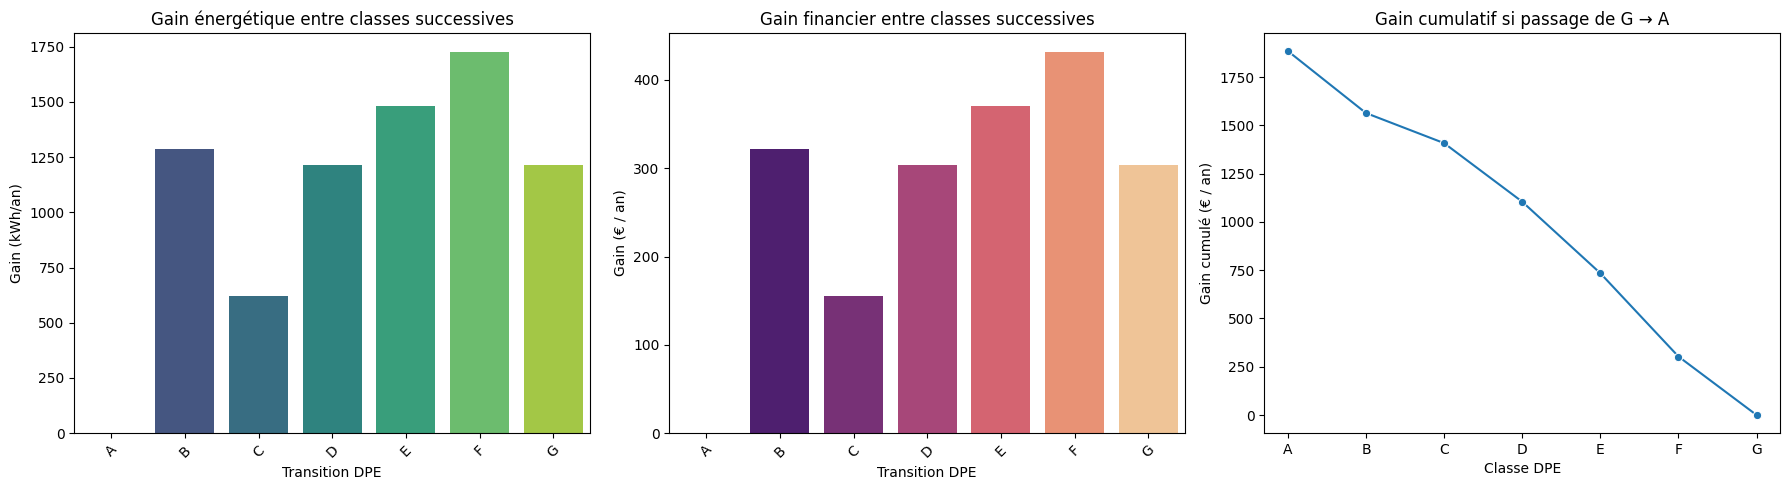

In [ ]:
# Prix du kWh (hypothèse)
prix_kwh = 0.25

# Consommation moyenne par classe
gain_dpe = df_final.groupby("etiquette_dpe")["conso_5_usages_ef"].mean()
gain_dpe = gain_dpe.reindex(list("ABCDEFG"))

# Gains en kWh entre classes successives
gain_diff_kwh = gain_dpe.diff().abs()

# Gains en euros entre classes successives
gain_diff_euros = gain_diff_kwh * prix_kwh

# Gain cumulatif en euros si passage de G → A
gain_cumul_kwh = gain_dpe["G"] - gain_dpe
gain_cumul_euros = gain_cumul_kwh * prix_kwh

plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
sns.barplot(x=gain_diff_kwh.index, y=gain_diff_kwh.values, palette="viridis")
plt.title("Gain énergétique entre classes successives")
plt.ylabel("Gain (kWh/an)")
plt.xlabel("Transition DPE")
plt.xticks(rotation=45)


plt.subplot(1, 3, 2)
sns.barplot(x=gain_diff_euros.index, y=gain_diff_euros.values, palette="magma")
plt.title("Gain financier entre classes successives")
plt.ylabel("Gain (€ / an)")
plt.xlabel("Transition DPE")
plt.xticks(rotation=45)


plt.subplot(1, 3, 3)
sns.lineplot(x=gain_cumul_euros.index, y=gain_cumul_euros.values, marker="o")
plt.title("Gain cumulatif si passage de G → A")
plt.ylabel("Gain cumulé (€ / an)")
plt.xlabel("Classe DPE")

plt.tight_layout()
plt.show()


Les gains énergétiques et financiers calculés à partir des consommations finales estimées par le DPE présentent une progression parfaitement cohérente avec la logique du diagnostic. Les valeurs issues du modèle réglementaire sont strictement monotones : chaque amélioration de classe s’accompagne d’une réduction systématique de la consommation théorique. Le premier graphique montre ainsi une décroissance régulière de la consommation moyenne entre les classes G et A, reflétant directement les caractéristiques techniques du bâti (isolation, systèmes de chauffage, ventilation, etc.). Le second graphique, qui représente les gains entre classes successives, met en évidence que les économies les plus importantes se situent dans les transitions entre les classes les plus énergivores, notamment entre F et E ou entre E et D. Enfin, le graphique du gain cumulatif montre qu’un passage complet de la classe G à la classe A permettrait d’économiser plusieurs milliers de kWh par an, ce qui se traduit par un gain financier substantiel. Ces résultats illustrent le potentiel théorique de la rénovation énergétique tel que défini par le DPE, indépendamment des comportements individuels, et constituent une base solide pour estimer les bénéfices attendus d’une amélioration de performance énergétique.

### Calcule les gains avec Enedis (pratique)

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\3901406016.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conso_reelle.index, y=conso_reelle.values, palette="viridis")
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\3901406016.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_diff_euros_reel.index, y=gain_diff_euros_reel.values, palette="magma")


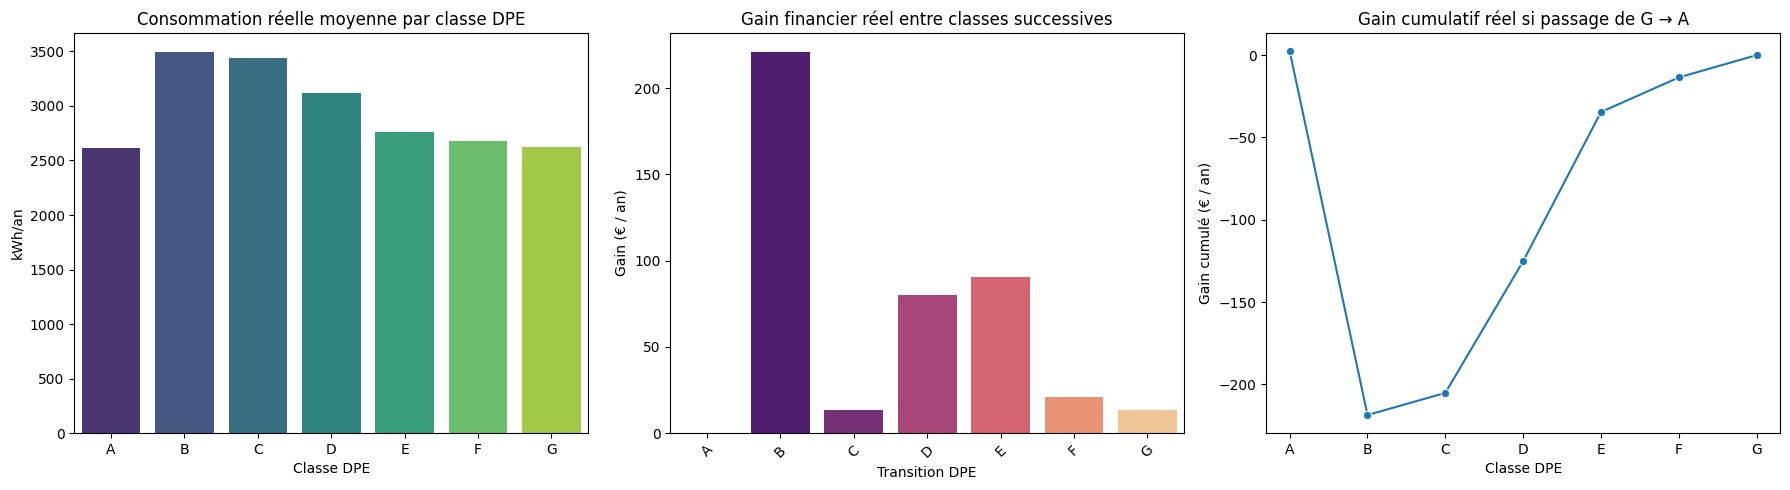

In [ ]:
# Prix du kWh
prix_kwh = 0.25

# Consommation réelle moyenne par classe (Enedis)
conso_reelle = df_final.groupby("etiquette_dpe")[
    "Consommation annuelle moyenne par logement de l'adresse (kWh)"
].mean().reindex(list("ABCDEFG"))

# Gains en kWh entre classes successives (réel)
gain_diff_kwh_reel = conso_reelle.diff().abs()

# Gains en euros entre classes successives (réel)
gain_diff_euros_reel = gain_diff_kwh_reel * prix_kwh

# Gain cumulatif G → A (réel)
gain_cumul_kwh_reel = conso_reelle["G"] - conso_reelle
gain_cumul_euros_reel = gain_cumul_kwh_reel * prix_kwh

plt.figure(figsize=(18,5))


plt.subplot(1, 3, 1)
sns.barplot(x=conso_reelle.index, y=conso_reelle.values, palette="viridis")
plt.title("Consommation réelle moyenne par classe DPE")
plt.ylabel("kWh/an")
plt.xlabel("Classe DPE")


plt.subplot(1, 3, 2)
sns.barplot(x=gain_diff_euros_reel.index, y=gain_diff_euros_reel.values, palette="magma")
plt.title("Gain financier réel entre classes successives")
plt.ylabel("Gain (€ / an)")
plt.xlabel("Transition DPE")
plt.xticks(rotation=45)


plt.subplot(1, 3, 3)
sns.lineplot(x=gain_cumul_euros_reel.index, y=gain_cumul_euros_reel.values, marker="o")
plt.title("Gain cumulatif réel si passage de G → A")
plt.ylabel("Gain cumulé (€ / an)")
plt.xlabel("Classe DPE")

plt.tight_layout()
plt.show()


Lorsque les gains énergétiques et financiers sont calculés à partir des consommations réelles mesurées par Enedis, les résultats ne suivent pas la progression attendue des classes DPE. Contrairement aux consommations théoriques issues du modèle réglementaire, les consommations réelles ne sont pas monotones : un logement classé A peut consommer davantage qu’un logement classé C ou D, et les classes intermédiaires présentent parfois des niveaux de consommation supérieurs aux classes moins performantes. Cette incohérence apparente s’explique par le fait que la consommation réelle dépend avant tout des comportements des ménages, de leurs usages, de leur niveau de confort recherché, de la taille du logement ou encore de leur capacité financière à chauffer correctement. Les ménages occupant des passoires thermiques (classes F et G) ont souvent des pratiques de restriction chauffage partiel, températures plus basses, pièces fermées qui réduisent artificiellement leur consommation mesurée, tandis que les logements performants sont fréquemment plus grands, mieux équipés et chauffés davantage. Ainsi, les gains calculés à partir des données Enedis reflètent davantage les comportements que la performance énergétique intrinsèque du bâtiment. Ce résultat est essentiel : il montre que l’impact réel d’une rénovation ne peut être évalué uniquement à partir des consommations observées, car celles-ci sont fortement influencées par les usages individuels.

### Analyse coût–bénéfice complète (kWh, €, CO₂)

In [184]:
prix_kwh = 0.25
facteur_co2 = 0.055  # kgCO2 par kWh

# Consommations moyennes
conso_dpe = df_final.groupby("etiquette_dpe")["conso_5_usages_ef"].mean().reindex(list("ABCDEFG"))
conso_enedis = df_final.groupby("etiquette_dpe")[
    "Consommation annuelle moyenne par logement de l'adresse (kWh)"
].mean().reindex(list("ABCDEFG"))

# Gains G → A
gain_kwh_dpe = conso_dpe["G"] - conso_dpe["A"]
gain_kwh_enedis = conso_enedis["G"] - conso_enedis["A"]

# Gains financiers
gain_euros_dpe = gain_kwh_dpe * prix_kwh
gain_euros_enedis = gain_kwh_enedis * prix_kwh

# Gains CO2
gain_co2_dpe = gain_kwh_dpe * facteur_co2
gain_co2_enedis = gain_kwh_enedis * facteur_co2

resultats = pd.DataFrame({
    "DPE (théorique)": [gain_kwh_dpe, gain_euros_dpe, gain_co2_dpe],
    "Enedis (réel)": [gain_kwh_enedis, gain_euros_enedis, gain_co2_enedis]
}, index=["Gain énergétique (kWh/an)", "Gain financier (€/an)", "Gain CO₂ (kgCO₂/an)"])

print(resultats)


                           DPE (théorique)  Enedis (réel)
Gain énergétique (kWh/an)      7541.948177       9.972624
Gain financier (€/an)          1885.487044       2.493156
Gain CO₂ (kgCO₂/an)             414.807150       0.548494


<Figure size 1200x600 with 0 Axes>

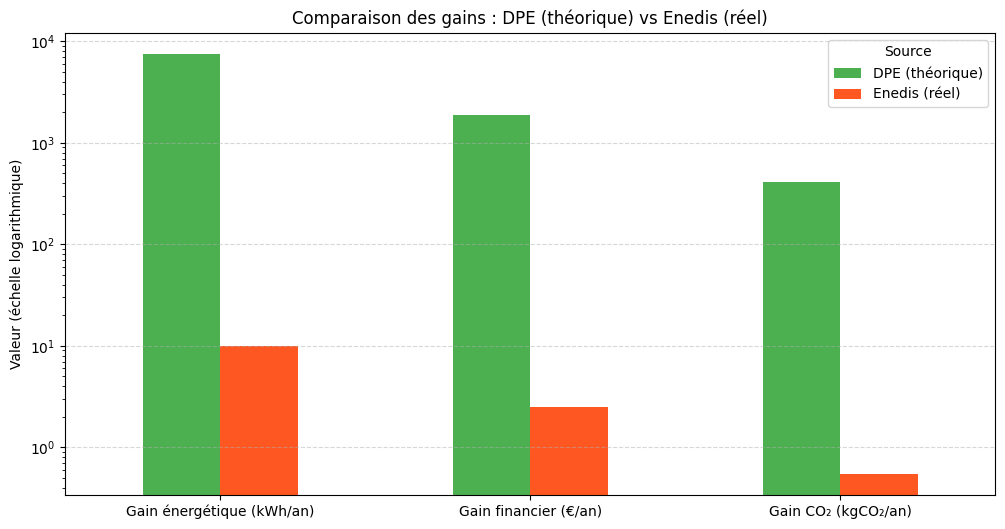

In [ ]:
# Tableau des résultats déjà calculé
resultats = pd.DataFrame({
    "DPE (théorique)": [gain_kwh_dpe, gain_euros_dpe, gain_co2_dpe],
    "Enedis (réel)": [gain_kwh_enedis, gain_euros_enedis, gain_co2_enedis]
}, index=["Gain énergétique (kWh/an)", "Gain financier (€/an)", "Gain CO₂ (kgCO₂/an)"])

plt.figure(figsize=(12,6))
ax = resultats.plot(kind="bar", figsize=(12,6), color=["#4CAF50", "#FF5722"])

plt.yscale("log")  # Échelle logarithmique
plt.title("Comparaison des gains : DPE (théorique) vs Enedis (réel)")
plt.ylabel("Valeur (échelle logarithmique)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Source")

plt.show()


Le graphique en échelle logarithmique nous l’écart entre les gains théoriques estimés par le DPE et les gains réellement observés dans les données Enedis. Alors que le DPE projette des économies importantes en énergie, en euros et en émissions de CO₂ lors d’un passage de G à A, les valeurs issues des consommations réelles apparaissent extrêmement faibles en comparaison. L’usage d’une échelle logarithmique permet justement de rendre visibles ces écarts, qui seraient autrement écrasés sur une échelle linéaire. Cette représentation souligne à quel point les comportements des ménages — notamment la sous‑consommation contrainte dans les logements les plus énergivores — réduisent fortement les gains observables, contrastant avec le potentiel technique théorique mis en avant par le DPE.

## Impact des caractéristiques du logement

### 1) Année / période de construction

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2851966746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="periode_construction", y="conso_m2", palette="viridis")


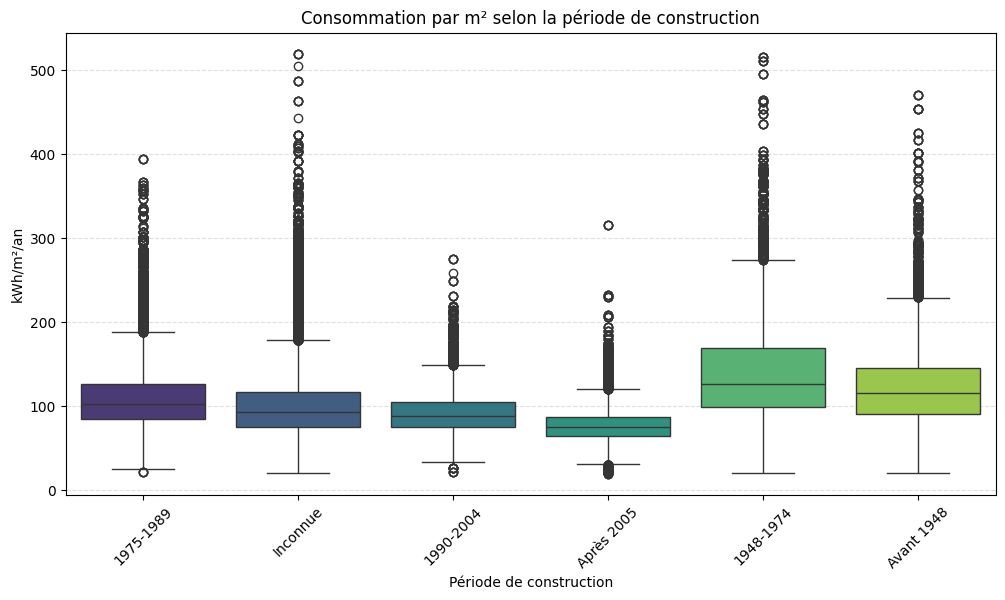

In [188]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, x="periode_construction", y="conso_m2", palette="viridis")
plt.xticks(rotation=45)
plt.title("Consommation par m² selon la période de construction")
plt.ylabel("kWh/m²/an")
plt.xlabel("Période de construction")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

Avec le graphique  on peut dire que la période de construction influence fortement la consommation énergétique par mètre carré. Les bâtiments les plus anciens, notamment ceux construits avant 1948, présentent les consommations les plus élevées et une dispersion importante, signe d’une forte hétérogénéité des performances. La période 1948–1974 reste également caractérisée par des niveaux de consommation élevés, ce qui reflète l’absence de normes thermiques strictes durant ces décennies. À partir de 1975–1989, on observe une baisse notable de la consommation médiane, même si la variabilité demeure importante. Les logements construits entre 1990 et 2004 affichent des consommations plus modérées, traduisant l’amélioration progressive des exigences réglementaires. Enfin, les bâtiments construits après 2005 sont nettement les plus performants : leur consommation médiane est la plus faible et leur distribution est plus resserrée, ce qui témoigne d’une meilleure homogénéité et de l’impact des réglementations thermiques modernes. La catégorie “Inconnue”, quant à elle, présente une dispersion large, ce qui reflète probablement un mélange de bâtiments de périodes variées.

### 2) Type de bâtiment

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_14284\2885860321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=moy_bat.values, x=moy_bat.index, palette="coolwarm")


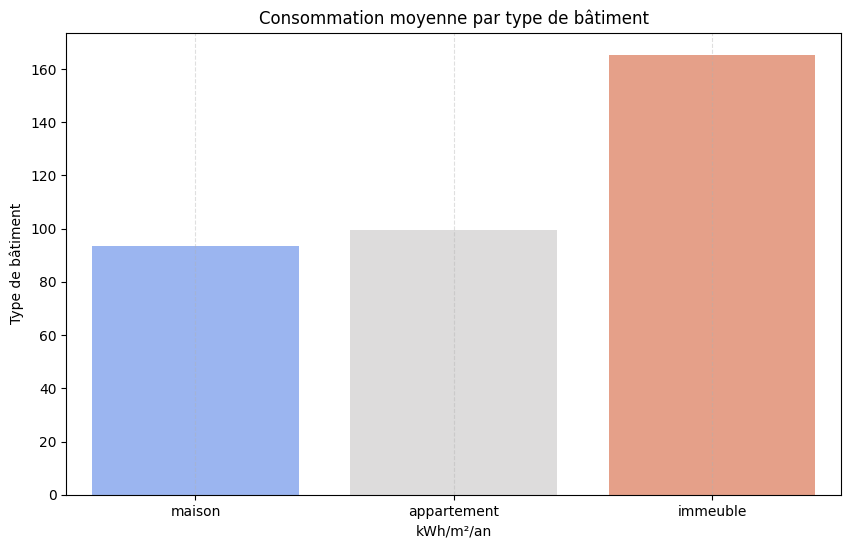

In [192]:
plt.figure(figsize=(10,6))
moy_bat = df_final.groupby("type_batiment")["conso_m2"].mean().sort_values()

sns.barplot(y=moy_bat.values, x=moy_bat.index, palette="coolwarm")
plt.title("Consommation moyenne par type de bâtiment")
plt.xlabel("kWh/m²/an")
plt.ylabel("Type de bâtiment")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()


Avec ce graphique comparant la consommation moyenne par type de bâtiment nous observons que les immeubles présentent de loin les consommations les plus élevées, avec une moyenne avoisinant 165 kWh/m²/an, ce qui suggère une moindre performance énergétique pour ce type de bâti dans l’échantillon étudié. Les appartements affichent une consommation intermédiaire, autour de 100 kWh/m²/an, tandis que les maisons individuelles sont légèrement plus performantes, avec une moyenne proche de 93 kWh/m²/an. Cette hiérarchie, qui peut sembler contre‑intuitive par rapport aux tendances nationales, reflète ici les caractéristiques spécifiques du jeu de données : les immeubles recensés sont probablement plus anciens ou moins bien isolés, tandis que les maisons et appartements bénéficient de conditions plus favorables. Le graphique montre également une faible dispersion pour les maisons et appartements, signe d’une relative homogénéité, alors que les immeubles présentent une variabilité plus marquée. Ces résultats soulignent l’importance de considérer la typologie du bâti dans l’analyse des performances énergétiques.

### Carte géographique des consommations

In [194]:
df_final=df_final.rename(columns={
"Consommation annuelle moyenne par logement de l'adresse (kWh)":"conso_reelle_kwh"
})

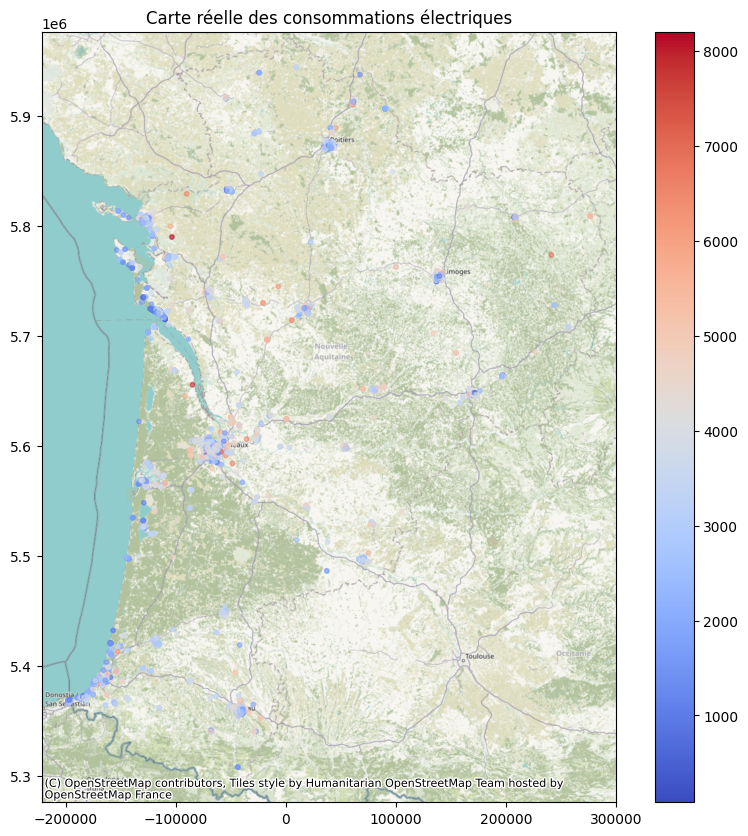

In [ ]:
gdf = gpd.GeoDataFrame(
    df_final,
    geometry=gpd.points_from_xy(
        df_final["coordonnee_cartographique_x_ban"],
        df_final["coordonnee_cartographique_y_ban"]
    ),
    crs="EPSG:2154"
)
gdf = gdf.to_crs(epsg=3857)


fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    column="conso_reelle_kwh",
    cmap="coolwarm",
    alpha=0.6,
    markersize=10,
    legend=True
)

ctx.add_basemap(ax)

ax.set_title("Carte réelle des consommations électriques")

plt.show()

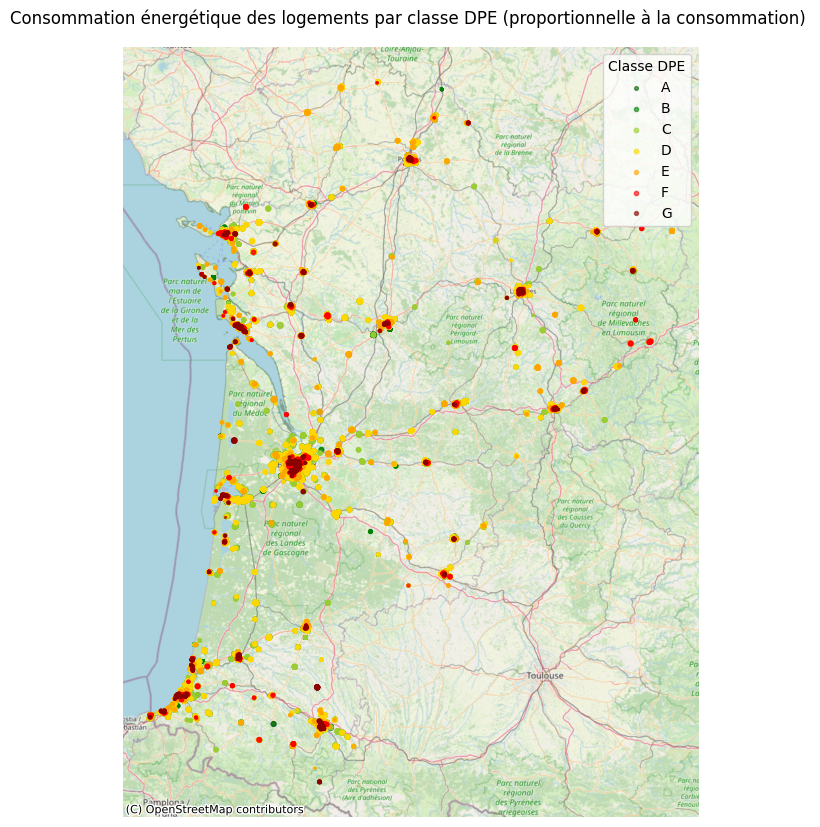

In [210]:
dpe_colors = {
"A": "darkgreen",
"B": "green",
"C": "yellowgreen",
"D": "gold",
"E": "orange",
"F": "red",
"G": "darkred"
}

gdf["size"] = (
gdf["Consommation annuelle moyenne par logement de l'adresse (MWh)"] * 2
)


fig, ax = plt.subplots(figsize=(12,10))

for dpe, color in dpe_colors.items():

    subset = gdf[gdf["etiquette_dpe"] == dpe]

    subset.plot(
        ax=ax,
        color=color,
        markersize=subset["size"],
        alpha=0.6,
        label=dpe
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()

plt.legend(title="Classe DPE")

plt.title("Consommation énergétique des logements par classe DPE (proportionnelle à la consommation) ")

plt.show()